In [25]:
import sys
import time
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm)

<module 'exp_pybamm' from '/Users/noord/Library/CloudStorage/OneDrive-Chalmers/Master2/MSc_thesis/program/PINN/../exp_pybamm.py'>

In [ ]:
# Directory of THIS script
BASE_DIR = Path.cwd()
I = np.load(BASE_DIR.parent / 'NO/data_NO/I.npz')['arr_0']   # [N,1,1000]
V = np.load(BASE_DIR.parent / 'NO/data_NO/V.npz')['arr_0']   # [N,1,1000]

test_size = 0.1
split = int(test_size * len(I))

I_test = I[:split]
V_test = V[:split]
I_train = I[split:]
V_train = V[split:]

# Convert to PyTorch tensors
train_dataset = TensorDataset(
    torch.tensor(I_train, dtype=torch.float32),
    torch.tensor(V_train, dtype=torch.float32)
)

loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [26]:
'''
Setup
'''

model = nn.Sequential(
    nn.Linear(1000, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 1000)
)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# loss functions
def data_loss(u_pred, u_true):
    loss_fn = nn.MSELoss()
    return loss_fn(u_pred, u_true)


# time points (collocation)
t = torch.linspace(0, 1, 100).view(-1,1)
t.requires_grad = True

def physics_loss(u, t):
    # compute du/dt
    du_dt = torch.autograd.grad(outputs=u, inputs=t,
                                grad_outputs=torch.ones_like(u), create_graph=True)[0]
    # PDE residual for du/dt + u = 0
    return torch.mean((du_dt + u)**2)

In [32]:
def training(epochs=50, tol=2.5e-4, loader=loader, model=model, optimizer=optimizer):
    history = {'loss': []}
    
    for epoch in range(epochs):
        loss_sum = 0
        nb = 0
        start_b = time.perf_counter()

        for u_batch, y_batch in loader:
            # reshape: [B,1,1000] → [B,1000]
            u_batch = u_batch.squeeze(1)
            y_batch = y_batch.squeeze(1)

            y_pred = model(u_batch)

            d_loss = data_loss(y_pred, y_batch)
            loss = d_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        #     loss_sum += loss.item()
        #     nb += 1

        # end_b = time.perf_counter()
        # avg_loss = loss_sum / nb
        # ETA = (end_b-start_b)*(epochs-epoch-1)

        history['loss'].append(loss.item())

        if loss < tol:
            print(f'Epoch {epoch+1} loss: {loss:.5f} - Early stopping')
            break

        print(f'Epoch {epoch+1} loss: {loss:.5f}')

    return model, history

In [33]:
model, history = training(epochs=50, model=model, optimizer=optimizer)

Epoch 1 loss: 0.00732
Epoch 2 loss: 0.00529
Epoch 3 loss: 0.00509
Epoch 4 loss: 0.00410
Epoch 5 loss: 0.00552
Epoch 6 loss: 0.00422
Epoch 7 loss: 0.00666
Epoch 8 loss: 0.00455
Epoch 9 loss: 0.00498
Epoch 10 loss: 0.00356
Epoch 11 loss: 0.00419
Epoch 12 loss: 0.00437
Epoch 13 loss: 0.00448
Epoch 14 loss: 0.00423
Epoch 15 loss: 0.00376
Epoch 16 loss: 0.00341
Epoch 17 loss: 0.00335
Epoch 18 loss: 0.00445
Epoch 19 loss: 0.00347
Epoch 20 loss: 0.00480
Epoch 21 loss: 0.00275
Epoch 22 loss: 0.00347
Epoch 23 loss: 0.00390
Epoch 24 loss: 0.00359
Epoch 25 loss: 0.00257
Epoch 26 loss: 0.00342
Epoch 27 loss: 0.00341
Epoch 28 loss: 0.00246
Epoch 29 loss: 0.00242
Epoch 30 loss: 0.00320
Epoch 31 loss: 0.00259
Epoch 32 loss: 0.00290
Epoch 33 loss: 0.00240
Epoch 34 loss: 0.00224
Epoch 35 loss: 0.00209
Epoch 36 loss: 0.00233
Epoch 37 loss: 0.00243
Epoch 38 loss: 0.00207
Epoch 39 loss: 0.00253
Epoch 40 loss: 0.00216
Epoch 41 loss: 0.00198
Epoch 42 loss: 0.00223
Epoch 43 loss: 0.00224
Epoch 44 loss: 0.002

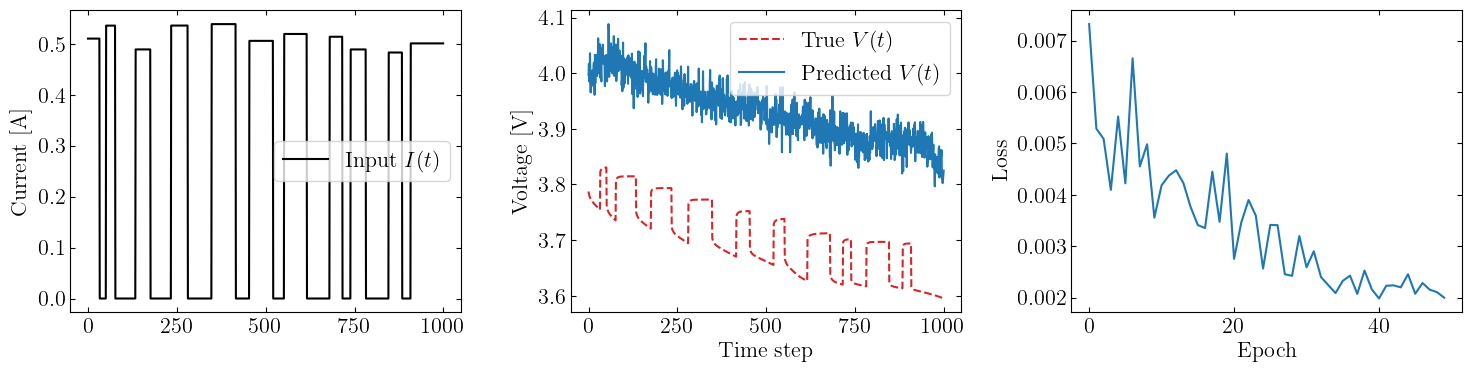

In [40]:
test = 1
i = I_test[test]
v = V_test[test]

i_tensor = torch.tensor(i, dtype=torch.float32).squeeze(0).unsqueeze(0)

with torch.no_grad():
    y_pred = model(i_tensor)

# Plot
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))

ax1.plot(i.ravel(), label='Input $I(t)$', color='black')
ax2.plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
ax2.plot(y_pred.detach().numpy().ravel(), label='Predicted $V(t)$', color='tab:blue')

ax2.legend()
ax1.legend()
ax2.set_xlabel('Time step')
ax1.set_ylabel('Current [A]')
ax2.set_ylabel('Voltage [V]')

ax3.plot(history['loss'])
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')  
plt.tight_layout()